In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [2]:
import numpy as np
import copy
import matplotlib.pyplot as plt
import h5py
import scipy
from PIL import Image
from scipy import ndimage

from utils.lr_utils import load_dataset, initialize_with_zeros
from activations.sigmoid import sigmoid
from calculations.propagation import propagate
from optimizers.optimize import optimize
from utils.predict import predict
from model.model import model

%matplotlib inline
%load_ext autoreload
%autoreload 2

[ 6.98721037e+00 -3.17851154e-03  7.99462810e+00 -1.33960117e-03
  8.99777780e+00 -5.54967259e-04]
[ 6.98721037e+00 -3.17851154e-03  7.99462810e+00 -1.33960117e-03
  8.99777780e+00 -5.54967259e-04]
[ 0.46211716 -0.46211716  0.90514825 -0.90514825  0.99505475 -0.99505475]


In [3]:
# Loading the data (cat/non-cat)
train_set_x_orig, train_set_y, test_set_x_orig, test_set_y, classes = load_dataset()

y = [1], it's a 'cat' picture.


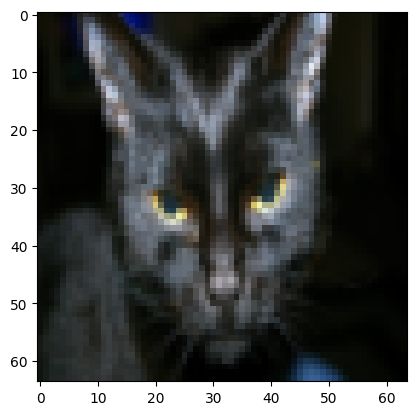

In [4]:
# Example of a picture
index = 25
plt.imshow(train_set_x_orig[index])
print ("y = " + str(train_set_y[:, index]) + ", it's a '" + classes[np.squeeze(train_set_y[:, index])].decode("utf-8") +  "' picture.")

In [5]:
m_train = train_set_x_orig.shape[0]
m_test = test_set_x_orig.shape[0]
num_px = train_set_x_orig.shape[1]

print ("Number of training examples: m_train = " + str(m_train))
print ("Number of testing examples: m_test = " + str(m_test))

print ("Each image is of size: (" + str(num_px) + ", " + str(num_px) + ", 3)")

print ("train_set_x shape: " + str(train_set_x_orig.shape))
print ("train_set_y shape: " + str(train_set_y.shape))

print ("test_set_x shape: " + str(test_set_x_orig.shape))
print ("test_set_y shape: " + str(test_set_y.shape))

Number of training examples: m_train = 209
Number of testing examples: m_test = 50
Each image is of size: (64, 64, 3)
train_set_x shape: (209, 64, 64, 3)
train_set_y shape: (1, 209)
test_set_x shape: (50, 64, 64, 3)
test_set_y shape: (1, 50)


In [6]:
train_set_x_flatten = train_set_x_orig.reshape(train_set_x_orig.shape[0], -1).T
test_set_x_flatten = test_set_x_orig.reshape(test_set_x_orig.shape[0], -1).T

# Check that the first 10 pixels of the second image are in the correct place
assert np.all(train_set_x_flatten[0:10, 1] == [196, 192, 190, 193, 186, 182, 188, 179, 174, 213]), "Wrong solution. Use (X.shape[0], -1).T."
assert np.all(test_set_x_flatten[0:10, 1] == [115, 110, 111, 137, 129, 129, 155, 146, 145, 159]), "Wrong solution. Use (X.shape[0], -1).T."

print ("train_set_x_flatten shape: " + str(train_set_x_flatten.shape))
print ("train_set_y shape: " + str(train_set_y.shape))
print ("test_set_x_flatten shape: " + str(test_set_x_flatten.shape))
print ("test_set_y shape: " + str(test_set_y.shape))

train_set_x_flatten shape: (12288, 209)
train_set_y shape: (1, 209)
test_set_x_flatten shape: (12288, 50)
test_set_y shape: (1, 50)


In [7]:
train_set_x = train_set_x_flatten / 255.
test_set_x = test_set_x_flatten / 255.

In [8]:
logistic_regression_model = model(train_set_x, train_set_y, test_set_x, test_set_y, num_iterations=4000, learning_rate=0.0035, print_cost=True)

Cost after iteration 0: 0.693147
Cost after iteration 100: 0.517377
Cost after iteration 200: 0.455977
Cost after iteration 300: 0.412609
Cost after iteration 400: 0.378835
Cost after iteration 500: 0.351244
Cost after iteration 600: 0.328017
Cost after iteration 700: 0.308051
Cost after iteration 800: 0.290617
Cost after iteration 900: 0.275205
Cost after iteration 1000: 0.261446
Cost after iteration 1100: 0.249062
Cost after iteration 1200: 0.237839
Cost after iteration 1300: 0.227607
Cost after iteration 1400: 0.218231
Cost after iteration 1500: 0.209602
Cost after iteration 1600: 0.201629
Cost after iteration 1700: 0.194235
Cost after iteration 1800: 0.187357
Cost after iteration 1900: 0.180942
Cost after iteration 2000: 0.174941
Cost after iteration 2100: 0.169316
Cost after iteration 2200: 0.164031
Cost after iteration 2300: 0.159056
Cost after iteration 2400: 0.154365
Cost after iteration 2500: 0.149932
Cost after iteration 2600: 0.145738
Cost after iteration 2700: 0.141764
Cost

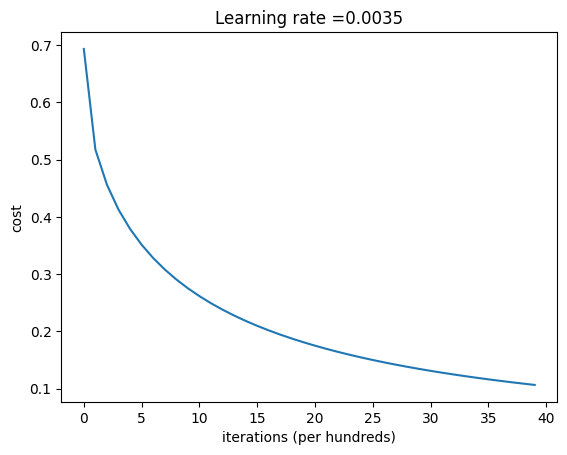

In [9]:
# Plot learning curve (with costs)
costs = np.squeeze(logistic_regression_model['costs'])
plt.plot(costs)
plt.ylabel('cost')
plt.xlabel('iterations (per hundreds)')
plt.title("Learning rate =" + str(logistic_regression_model["learning_rate"]))
plt.show()

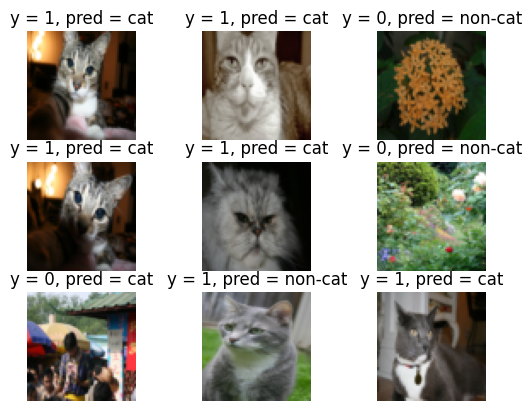

In [10]:
import random
random_indices = random.sample(range(test_set_x.shape[1]), 9)
for i, index in enumerate(random_indices):
    plt.subplot(3, 3, i+1)
    plt.imshow(test_set_x[:, index].reshape((num_px, num_px, 3)))
    plt.title("y = " + str(test_set_y[0,index]) + ", pred = " + classes[int(logistic_regression_model['Y_prediction_test'][0,index])].decode("utf-8"))
    plt.axis('off')
plt.show()

/tmp/ipykernel_54689/445019413.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title("pred = " + classes[int(pred)].decode("utf-8"))


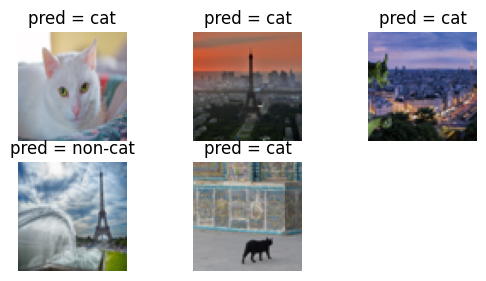

In [12]:

fname = "/home/iesus/Documents/deep_learning_experiments/data/imgs/cats"

for i, img_name in enumerate(os.listdir(fname)[:5]):
    img_path = os.path.join(fname, img_name)
    image = np.array(Image.open(img_path).resize((num_px, num_px)))
    plt.subplot(3, 3, i+1)
    plt.imshow(image)
    image = image / 255.
    image_flatten = image.reshape(1, -1).T
    pred = predict(logistic_regression_model['w'], logistic_regression_model['b'], image_flatten)
    plt.title("pred = " + classes[int(pred)].decode("utf-8"))
    plt.axis('off')
plt.show()